In [1]:
import seaborn
import pandas
import geopandas
import pysal
import numpy
import matplotlib.pyplot as plt

In [66]:
import os
# Check current working directory
print("Current working directory:", os.getcwd())

# List files in the current directory
print("Files in directory:", os.listdir())

Current working directory: c:\Users\User\.ipython\.venv\geopandas-coures-files\geopandas-coures-files\Spatial_Data_Analysis
Files in directory: ['Analysis1.ipynb', 'DSd.cpg', 'DSd.dbf', 'DSd.prj', 'DSd.sbn', 'DSd.sbx', 'DSd.shp', 'DSd.shp.xml', 'DSd.shx', 'Kandy_data.cpg', 'Kandy_data.dbf', 'Kandy_data.prj', 'Kandy_data.sbn', 'Kandy_data.sbx', 'Kandy_data.shp', 'Kandy_data.shp.xml', 'Kandy_data.shx', 'Nuwara_Data.cpg', 'Nuwara_Data.dbf', 'Nuwara_Data.prj', 'Nuwara_Data.sbn', 'Nuwara_Data.sbx', 'Nuwara_Data.shp', 'Nuwara_Data.shp.xml', 'Nuwara_Data.shx', 'Population_data.cpg', 'Population_data.dbf', 'Population_data.prj', 'Population_data.sbn', 'Population_data.sbx', 'Population_data.shp', 'Population_data.shp.xml', 'Population_data.shx']


In [11]:
mx = geopandas.read_file("Population_data.shp")
mx.head()

,OBJECTID,Shape_Leng,ADM3_EN,ADM2_EN,ADM1_EN,ADM0_EN,stats,Male,Female,Population,Density,HectRE,Settlement,H_Dens,Extend,Density_1,geometry
0,23,0.046173,Valikamam West (Chankanai),Jaffna,Northern,Sri Lanka,Vaddukoddai East,781,886,1667,13.824833,120.580122,464,3.848064,1.205801,1382.483256,"POLYGON ((79.96493 9.75211, 79.96495 9.75208, ..."
1,24,0.033428,Valikamam West (Chankanai),Jaffna,Northern,Sri Lanka,Vaddukoddai North,617,651,1268,27.754103,45.686939,408,8.930342,0.456869,2775.410272,"POLYGON ((79.95152 9.7533, 79.95154 9.75326, 7..."
2,25,0.084891,Valikamam West (Chankanai),Jaffna,Northern,Sri Lanka,Sangaraththai,939,996,1935,5.757153,336.103655,449,1.335897,3.361037,575.715250,"POLYGON ((79.96762 9.73633, 79.96748 9.73627, ..."
3,26,0.078511,Valikamam West (Chankanai),Jaffna,Northern,Sri Lanka,Araly West,673,697,1370,5.516594,248.341625,396,1.594578,2.483416,551.659433,"POLYGON ((79.93822 9.73455, 79.93841 9.73448, ..."
4,27,0.096757,Valikamam West (Chankanai),Jaffna,Northern,Sri Lanka,Araly Centre,1259,1389,2648,7.816088,338.788388,635,1.874326,3.387884,781.608843,"POLYGON ((79.95151 9.7255, 79.95164 9.72539, 7..."


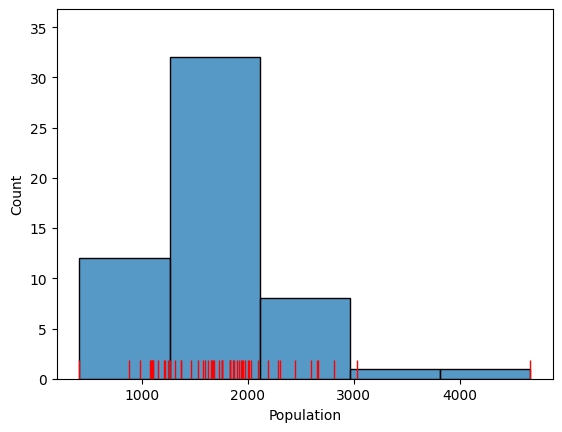

In [12]:
# Plot histogram
ax = seaborn.histplot(mx["Population"], bins=5)
# Add rug on horizontal axis
seaborn.rugplot(mx["Population"], height=0.05, color="red", ax=ax);

In [13]:
mx["Population"].describe()

count      54.000000
mean     1777.851852
std       656.060611
min       413.000000
25%      1327.250000
50%      1759.000000
75%      1997.000000
max      4663.000000
Name: Population, dtype: float64

In [14]:
counts, bins, patches = ax.hist(mx["Population"], bins=5)

In [15]:
counts

array([12., 32.,  8.,  1.,  1.])

In [16]:
bins

array([ 413., 1263., 2113., 2963., 3813., 4663.])

In [17]:
import mapclassify

In [ ]:
# Create 5 equal interval classes
ei5 = mapclassify.EqualInterval(mx["Population"], k=5)
ei5

EqualInterval

     Interval        Count
--------------------------
[ 413.00, 1263.00] |    12
(1263.00, 2113.00] |    32
(2113.00, 2963.00] |     8
(2963.00, 3813.00] |     1
(3813.00, 4663.00] |     1

In [19]:
# Create 5 quantile classes
q5 = mapclassify.Quantiles(mx.Population, k=5)
q5

Quantiles

     Interval        Count
--------------------------
[ 413.00, 1237.40] |    11
(1237.40, 1652.60] |    11
(1652.60, 1855.00] |    10
(1855.00, 2057.40] |    11
(2057.40, 4663.00] |    11

In [20]:
q5.bins[1:] - q5.bins[:-1]

array([ 415.2,  202.4,  202.4, 2605.6])

In [21]:
# Set seed for reproducibility
numpy.random.seed(12345)
# Generate a variable of 20 values randomly
# selected from 0 to 10
x = numpy.random.randint(0, 10, 20)
# Manually ensure the first ten values are 0 (the
# minimum value)
x[0:10] = x.min()
x

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 7, 6, 0, 2, 9, 1, 2, 6, 7],
      dtype=int32)

In [22]:
ties = mapclassify.Quantiles(x, k=5)
ties

c:\Users\User\.ipython\.venv\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


Quantiles

  Interval     Count
--------------------
[0.00, 0.00] |    11
(0.00, 1.40] |     1
(1.40, 6.20] |     4
(6.20, 9.00] |     4

In [23]:
ux = numpy.unique(x)
ux

array([0, 1, 2, 6, 7, 9], dtype=int32)

In [24]:
# Create standard mean deviation classes
msd = mapclassify.StdMean(mx["Population"])
msd

StdMean

     Interval        Count
--------------------------
[ 413.00,  465.73] |     1
( 465.73, 1121.79] |     7
(1121.79, 2433.91] |    39
(2433.91, 3089.97] |     6
(3089.97, 4663.00] |     1

In [26]:
# Create 5 maximum breaks classes
mb5 = mapclassify.MaximumBreaks(mx["Population"], k=5)
mb5

MaximumBreaks

     Interval        Count
--------------------------
[ 413.00,  647.50] |     1
( 647.50, 2373.00] |    46
(2373.00, 2920.50] |     5
(2920.50, 3845.00] |     1
(3845.00, 4663.00] |     1

In [30]:
# Create 5 box plot classes
bp = mapclassify.BoxPlot(mx["Population"])
bp

BoxPlot

     Interval        Count
--------------------------
(   -inf,  322.62] |     0
( 322.62, 1327.25] |    14
(1327.25, 1759.00] |    13
(1759.00, 1997.00] |    13
(1997.00, 3001.62] |    12
(3001.62, 4663.00] |     2

In [31]:
# Create 5 box plot classes with 1.5*IQR as the hinge
bp1 = mapclassify.BoxPlot(mx["Population"], hinge=1)
bp1

BoxPlot

     Interval        Count
--------------------------
[ 413.00,  657.50] |     1
( 657.50, 1327.25] |    13
(1327.25, 1759.00] |    13
(1759.00, 1997.00] |    13
(1997.00, 2666.75] |    11
(2666.75, 4663.00] |     3

In [32]:
# Create head-tail breaks classes
ht = mapclassify.HeadTailBreaks(mx["Population"])
ht

HeadTailBreaks

     Interval        Count
--------------------------
[ 413.00, 1777.85] |    29
(1777.85, 2264.96] |    16
(2264.96, 2827.11] |     7
(2827.11, 3845.00] |     1
(3845.00, 4663.00] |     1

In [ ]:
# Create 5 Jenks-Caspall classes
numpy.random.seed(12345)
jc5 = mapclassify.JenksCaspall(mx["Population"], k=5)
jc5

JenksCaspall

     Interval        Count
--------------------------
[ 413.00, 1268.00] |    13
(1268.00, 1599.00] |     7
(1599.00, 1831.00] |    12
(1831.00, 2299.00] |    15
(2299.00, 4663.00] |     7

In [36]:
numpy.random.seed(12345)
fj5 = mapclassify.FisherJenks(mx["Population"], k=5)
fj5

FisherJenks

     Interval        Count
--------------------------
[ 413.00, 1370.00] |    16
(1370.00, 1831.00] |    16
(1831.00, 2299.00] |    15
(2299.00, 3027.00] |     6
(3027.00, 4663.00] |     1

In [ ]:
# Create 5 maximum-p classes
mp5 = mapclassify.MaxP(mx["Population"], k=5)
mp5

MaxP

     Interval        Count
--------------------------
[ 413.00, 1313.00] |    14
(1313.00, 1830.00] |    17
(1830.00, 1861.00] |     2
(1861.00, 2287.00] |    13
(2287.00, 4663.00] |     8

C:\Users\User\AppData\Local\Temp\ipykernel_23492\9633576.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = seaborn.barplot(


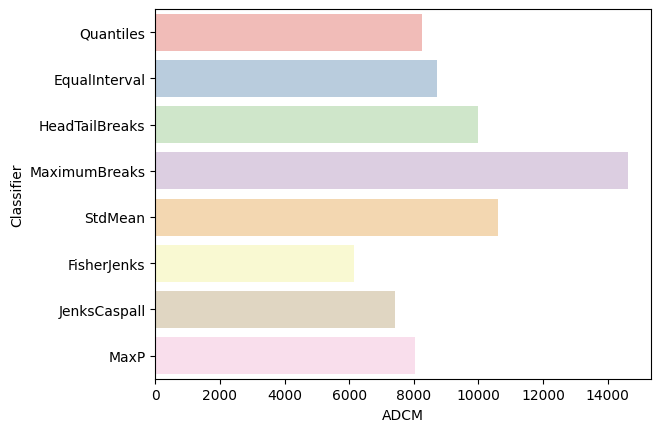

In [38]:
# Bunch classifier objects
class5 = q5, ei5, ht, mb5, msd, fj5, jc5, mp5
# Collect ADCM for each classifier
fits = numpy.array([c.adcm for c in class5])
# Convert ADCM scores to a DataFrame
adcms = pandas.DataFrame(fits)
# Add classifier names
adcms["classifier"] = [c.name for c in class5]
# Add column names to the ADCM
adcms.columns = ["ADCM", "Classifier"]
ax = seaborn.barplot(
    y="Classifier", x="ADCM", data=adcms, palette="Pastel1"
)

In [39]:
# Append class values as a separate column
mx["Quantiles"] = q5.yb
mx["Equal Interval"] = ei5.yb
mx["Head-Tail Breaks"] = ht.yb
mx["Maximum Breaks"] = mb5.yb
mx["Mean-Standard Deviation"] = msd.yb
mx["Fisher-Jenks"] = fj5.yb
mx["Jenks Caspall"] = jc5.yb
mx["MaxP"] = mp5.yb

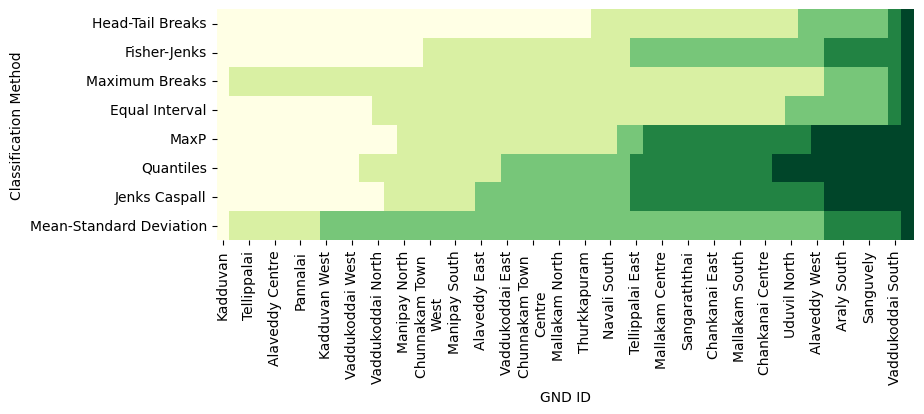

In [43]:
f, ax = plt.subplots(1, figsize=(9, 3))
seaborn.heatmap(
    mx.set_index("stats")
    .sort_values("Population")[
        [
            "Head-Tail Breaks",
            "Fisher-Jenks",
            "Maximum Breaks",
            "Equal Interval",
            "MaxP",
            "Quantiles",
            "Jenks Caspall",
            "Mean-Standard Deviation",
        ]
    ]
    .T,
    cmap="YlGn",
    cbar=False,
    ax=ax,
)
ax.set_ylabel("Classification Method");
ax.set_xlabel("GND ID");

In [44]:
pandas.DataFrame(
    {c.name: c.counts for c in class5},
    index=["Class-{}".format(i) for i in range(5)],
)

,Quantiles,EqualInterval,HeadTailBreaks,MaximumBreaks,StdMean,FisherJenks,JenksCaspall,MaxP
Class-0,11,12,29,1,1,16,13,14
Class-1,11,32,16,46,7,16,7,17
Class-2,10,8,7,5,39,15,12,2
Class-3,11,1,1,1,6,6,15,13
Class-4,11,1,1,1,1,1,7,8


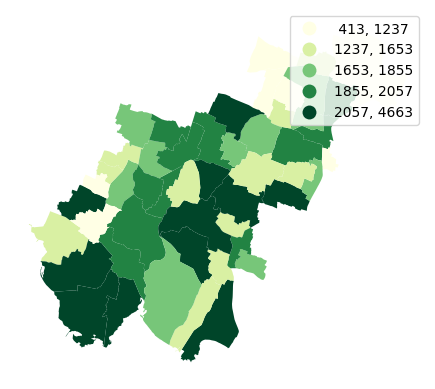

In [ ]:
ax = mx.plot(
    column="Population",  # Data to plot
    scheme="Quantiles",  # Classification scheme
    cmap="YlGn",  # Color palette
    legend=True,  # Add legend
    legend_kwds={"fmt": "{:.0f}"},  # Remove decimals in legend
)
ax.set_axis_off();

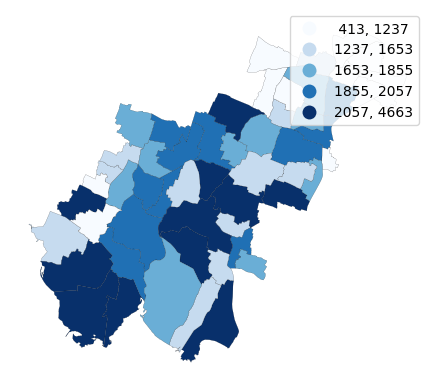

In [59]:

ax = mx.plot(
    column="Population",  # Data to plot
    scheme="Quantiles",  # Classification scheme
    cmap="Blues",  # Color palette
    edgecolor="k",  # Borderline color
    linewidth=0.1,  # Borderline width
    legend=True,  # Add legend
    legend_kwds={
        "fmt": "{:.0f}"
    },  # Remove decimals in legend (for legibility)
)
ax.set_axis_off();

In [63]:
mx = geopandas.read_file("Nuwara_Data.shp")
mx.head()

,OBJECTID,PROVINCE_N,DISTRICT_N,DSD_N,GND_N,Tot_Pop,Pop_2001,Builtup_ar,Road_Den,Pop_2011,Shape_Leng,Shape_Area,geometry
0,1,Central,Kandy,Delthota,Kotagepitiya,416,418.0,0.343404,0.377341,416,128.055395,0.056509,"POLYGON ((196474.355 218169.856, 196463.829 21..."
1,2,Central,Kandy,Delthota,Pattiyagama Gabadama Sou,987,0.0,0.102676,1.930418,987,108.934326,0.397005,"POLYGON ((193332.477 214499.764, 193306.032 21..."
2,3,Central,Kandy,Doluwa,Pupuressa,4769,5028.0,0.149626,2.975266,4769,588.583087,4.072902,"MULTIPOLYGON (((189102.583 210421.943, 189103...."
3,4,Central,Kandy,Kundasale,Aluth Pallekele,3185,2774.0,1.636714,4.444495,3185,3460.465121,49.708733,"MULTIPOLYGON (((197897.182 227707.447, 197897...."
4,5,Central,Kandy,Medadumbara,Thennalanda,522,504.0,0.679930,0.655262,522,707.588391,12.704533,"POLYGON ((202955.63 224177.97, 202955.628 2241..."


In [64]:
# Create income-based rank table (Rank 1 is highest)
rnk = mx[["GND_N", "Pop_2001", "Pop_2011"]].rank(ascending=False)
# Compute change from 1940 to 2000
rnk["change"] = rnk["Pop_2001"] - rnk["Pop_2011"]
# Add column with bin class
rnk["class"] = pandas.cut(rnk["change"], [-numpy.inf, -5, 0, 5, 20])

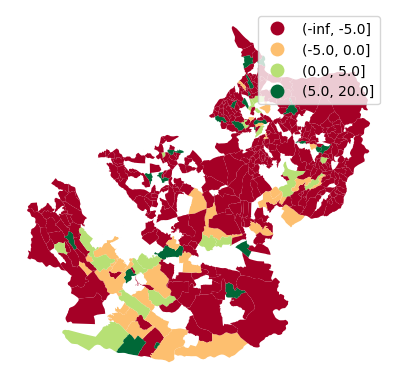

In [65]:
ax = (
    mx[["geometry"]]
    .join(rnk)
    .plot("class", legend=True, cmap="RdYlGn")
)
ax.set_axis_off();

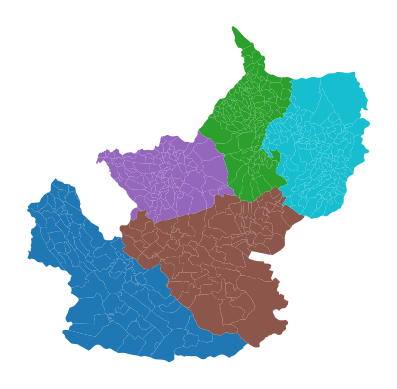

In [69]:
ax = mx.plot("DSD_N")
ax.set_axis_off();


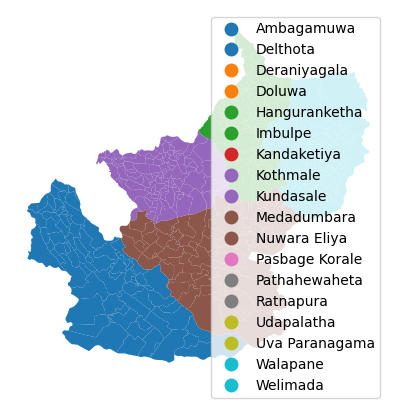

In [ ]:
#
ax = mx.plot("DSD_N", categorical=True, legend=True)
ax.set_axis_off();

In [74]:
classi = mapclassify.UserDefined(
    mx["Pop_2011"], [800, 1600, 2400, 3200, 4000,4800]
)
classi

UserDefined

     Interval        Count
--------------------------
[  58.00,  800.00] |   263
( 800.00, 1600.00] |   119
(1600.00, 2400.00] |    48
(2400.00, 3200.00] |    37
(3200.00, 4000.00] |    35
(4000.00, 4800.00] |    13
(4800.00, 7636.00] |    21

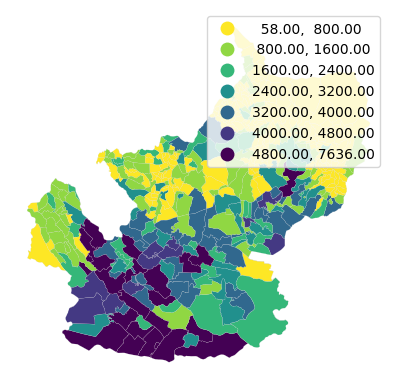

In [84]:
classi.plot(
    mx,  # Use geometries in the geo-table
    legend=True,  # Add a legend
    legend_kwds={
        "loc": "best"
    },  # Place legend on top right corner
    axis_on=False,  # Remove axis
    cmap="viridis_r",  # Use reverse Viridis
);

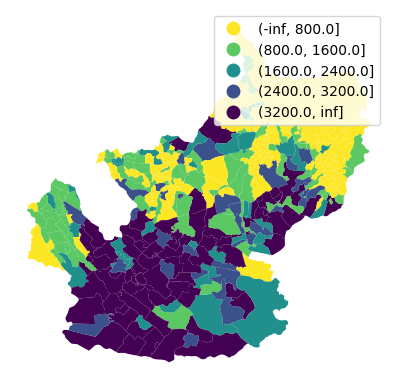

In [86]:
# Classify values specifying bins
lbls = pandas.cut(
    mx["Pop_2011"], [-numpy.inf, 800, 1600, 2400, 3200, numpy.inf]
)
# Dynamically assign to geo-table and plot with a legend
ax = mx.plot(lbls, cmap="viridis_r", legend=True)
# Remove axis
ax.set_axis_off();

In [ ]:
# List the years we want of pc GDP
years = ["PCGDP1940", "PCGDP1960", "PCGDP1980", "PCGDP2000"]
# Create pooled classification
pooled = mapclassify.Pooled(mx[years], classifier="Quantiles", k=5)
# Set up figure with four axis
f, axs = plt.subplots(2, 2, figsize=(12, 12))
# Flatten the array of axis so you can loop over
# in one dimension
axs = axs.flatten()
# Loop over each year
for i, y in enumerate(years):
    mx.plot(
        y,  # Year to plot
        scheme="UserDefined",  # Use our own bins
        classification_kwds={
            "bins": pooled.global_classifier.bins
        },  # Use global bins
        legend=True,  # Add a legend
        ax=axs[i],  # Plot on the corresponding axis
    )
    # Remove axis
    axs[i].set_axis_off()
    # Name the subplot with the name of the column
    axs[i].set_title(y)
# Tight layout to better use space
plt.tight_layout()
# Display figure
plt.show()